<a href="https://colab.research.google.com/github/CosmicVoid/Chest-X-Ray-AI-Detection/blob/main/Chest_Xray_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
#In case you don't have it installed
#!pip install kagglehub

In [ ]:
#Kagglehub to download the data
import kagglehub

# File Extraction & Management
import os
import zipfile
import shutil

# Pytorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils as utils

import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Result Visualization
import matplotlib.pyplot as plt
import numpy
import seaborn
from sklearn.metrics import confusion_matrix, classification_report

# Dataset

In [ ]:
# Download Found Kaggle Dataset
path = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", path)

100%|██████████| 1.74G/1.74G [00:20<00:00, 92.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis/versions/1


In [ ]:
# View Directory
print("Main Directory: ")
print(os.listdir(path))
print("Training: ")
print(os.listdir(path + "/train"))
print("Testing: ")
print(os.listdir(path + "/test"))
print("Validation: ")
print(os.listdir(path + "/val"))

Main Directory: 
['test', 'train', 'val']
Training: 
['COVID19', 'TURBERCULOSIS', 'PNEUMONIA', 'NORMAL']
Testing: 
['COVID19', 'TURBERCULOSIS', 'PNEUMONIA', 'NORMAL']
Validation: 
['COVID19', 'TURBERCULOSIS', 'PNEUMONIA', 'NORMAL']


In [ ]:
# Set an Image Transformation into a format ResNet-18 can process
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Setting all images to 224 x 224
    transforms.Grayscale(num_output_channels = 3), # ResNet-18 is built for color images (3 channels), so this conversion is necessary
    transforms.ToTensor(), # Converts images into math matrices, or Tensors
    transforms.Normalize(mean = [.485, .456, .406], std = [.229, .224, .225]) # To center the dataset values around 0.0 so it matches ResNet-18's original averages to stabilize the calculations
])

In [ ]:
# Create the Datasets from the folder and Applying the transformation
train_dataset = datasets.ImageFolder(root = path + '/train', transform = transform)
test_dataset = datasets.ImageFolder(root = path + '/test', transform = transform)
val_dataset = datasets.ImageFolder(root = path + '/val', transform = transform)

print(f"{len(train_dataset)} training images")
print(f"{len(test_dataset)} testing images")
print(f"{len(val_dataset)} validation images")
print(f"Class Mapping (Alphabetical Order): {train_dataset.class_to_idx}") # To check the number labels given to the 4 categories

6326 training images
771 testing images
38 validation images
Class Mapping (Alphabetical Order): {'COVID19': 0, 'NORMAL': 1, 'PNEUMONIA': 2, 'TURBERCULOSIS': 3}


In [ ]:
# Create a DataLoader, which groups the data in batches (shuffling can be applied to reduce overfitting during training)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
# Verifying the Success of the Process
images, labels = next(iter(train_loader)) # Gets the first item (image information) from a loader and then the next item (labels)
print("Batch image shape: ", images.shape) # Info should be [32, 3, 224, 224] (batch size 32, 3 channels, and size of 224x224)
print("Batch labels: ", labels) # Should be a List of 32 random numbers between 0 and 3 (there are 4 labels) (checking shuffling)

Batch image shape:  torch.Size([32, 3, 224, 224])
Batch labels:  tensor([2, 1, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 2,
        3, 2, 1, 2, 2, 1, 2, 2])


# Model Architecture

In [ ]:
# Load the Pre-trained ResNet-18 Model instance
model = torchvision.models.resnet18(weights = torchvision.models.ResNet18_Weights.DEFAULT) # Using Default Weights

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 168MB/s]


In [ ]:
# Freeze the Core Layers first so the pre-trained knowledge doesn't get overwritten
for parameter in model.parameters():
    parameter.requires_grad = False

In [ ]:
# Since ResNet-18 is built to classify 1,000 different types of objects, we need to replace the fully-connected layer (fc) with one built for our 4 outputs
model.fc = nn.Linear(model.fc.in_features, 4) # Connecting the number of input features to the 4 outputs

In [ ]:
# Move the model to GPU if available/applicable for faster training
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda:0


### Note for Colab Users:

To significantly speed up training, make sure to run this notebook on a GPU runtime. You can enable a GPU by going to `Runtime` -> `Change runtime type` -> select `GPU` as the hardware accelerator.

In [ ]:
# Print the model architecture to verify the modified final layer
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Optimization

In [ ]:
# Define the Loss Function, which will evaluate the error of the prediction
loss_function = nn.CrossEntropyLoss()
# For multi-class classification, CrossEntropyLoss is appropriate since it converts the output to a probability distribution and more heavily punishes incorrect classification.

In [ ]:
# Define the Optimizer which will tune the parameters to minimize loss (Adam is a popular choice that often performs well, and a common starting learning rate for Adam is 0.001.)
optimizer = optim.Adam(model.parameters(), lr = 0.001) # Pass model.parameters to tell it which tensors to manage

# Training

In [ ]:
epochs = 10 # Tested so Far: 5, 10

for epoch in range(epochs):
    ''' TRAINING '''
    # Put the model in training mode
    model.train()

    # To Track the loss as the model trains
    total_train_loss = 0.0

    # Loop through the Data in the Training Dataloader
    for inputs, labels in train_loader:
        # Move the data to GPU to make sure it is on the same device as the model (like previously, will not change if no gpu is present)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Reset/Clear Gradients
        optimizer.zero_grad()

        # Forward Pass - "Passing" the input to the model
        outputs = model(inputs)

        # Calculate Loss - putting the outputs and labels into the loss function
        loss = loss_function(outputs, labels)

        # Backward Pass / Backpropagation - Calculating the Gradient of the Loss
        loss.backward()

        # Update Parameters with the Optimizer
        optimizer.step()

        # Add the loss to the total
        total_train_loss += loss.item() # .item() converts the tensor([loss_value]) into an integer


    ''' VALIDATION '''
    # Put the model in evaluation mode for validation (checking model performance on unfamiliar data - may reveal overfitting)
    model.eval()

    # Track Loss and Number of Correct Predictions during Validation
    total_val_loss = 0.0
    total_correct_val = 0
    total_val_samples = 0 # Track total number of samples for accuracy calculation

    # Make sure that gradient tracking is disabled for validation since it is unnecessary
    with torch.no_grad():
        for inputs, labels in val_loader:
            # Move the data to GPU (or not)
            inputs = inputs.to(device)
            labels = labels.to(device)

            # Pass the Input to the Model
            val_outputs = model(inputs)

            # Calculate Loss
            val_loss = loss_function(val_outputs, labels)

            # Add to Total Loss
            total_val_loss += val_loss.item()

            # Get the predicted class for each sample in the batch (torch.argmax returns a tensor (1 row) of indices of the maximum values along a given dimension in a tensor)
            predicted_classes = torch.argmax(val_outputs, dim = 1) # This will return the column indices of the maximum values in each row (each row stores the output probability scores for each sample)

            # Compare predictions to actual labels to count correct predictions
            total_correct_val += (predicted_classes == labels).sum().item() # PyTorch tensors treat True/False as 1/0 in arithmetic operations, so this is a more compact way to count
            total_val_samples += labels.size(0) # Add batch size to sample count


    ''' EPOCH SUMMARY '''
    # Calculate validation accuracy
    val_accuracy = (total_correct_val / total_val_samples if total_val_samples > 0 else 0.0) * 100.0

    # Print average loss for training and validation as well as the validation accuracy at the end of each epoch
    print(f"Epoch {epoch+1}/{epochs} | Avg Train Loss: {total_train_loss / len(train_loader):.4f} | Avg Val Loss: {total_val_loss / len(val_loader):.4f} | Val Accuracy: {val_accuracy:.4f}%")

Epoch 1/10 | Avg Train Loss: 0.4630 | Avg Val Loss: 0.6078 | Val Accuracy: 73.6842%
Epoch 2/10 | Avg Train Loss: 0.2438 | Avg Val Loss: 0.4382 | Val Accuracy: 76.3158%
Epoch 3/10 | Avg Train Loss: 0.1872 | Avg Val Loss: 0.5131 | Val Accuracy: 71.0526%
Epoch 4/10 | Avg Train Loss: 0.1636 | Avg Val Loss: 0.4580 | Val Accuracy: 78.9474%
Epoch 5/10 | Avg Train Loss: 0.1568 | Avg Val Loss: 0.4227 | Val Accuracy: 78.9474%
Epoch 6/10 | Avg Train Loss: 0.1449 | Avg Val Loss: 0.2673 | Val Accuracy: 86.8421%
Epoch 7/10 | Avg Train Loss: 0.1407 | Avg Val Loss: 0.2922 | Val Accuracy: 86.8421%
Epoch 8/10 | Avg Train Loss: 0.1361 | Avg Val Loss: 0.4323 | Val Accuracy: 73.6842%
Epoch 9/10 | Avg Train Loss: 0.1233 | Avg Val Loss: 0.2603 | Val Accuracy: 86.8421%
Epoch 10/10 | Avg Train Loss: 0.1268 | Avg Val Loss: 0.3071 | Val Accuracy: 81.5789%


# Testing & Results

In [ ]:
# Make sure the model is in evaluation mode
model.eval()

# Testing should not be too different from validation, since it is the final evaluation of the model
total_correct_test = 0
total_test_samples = 0

# ***Collect a list of the predictions and labels to organize our results later in a more comprehensive way***
all_predictions = []
all_labels = []

# Make sure that gradient tracking is disabled
with torch.no_grad():
    for inputs, labels in test_loader:
        # Move the data to GPU (or not)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Pass the Input to the Model
        test_outputs = model(inputs)

        # Get the predicted class for each sample in the batch
        predictions = torch.argmax(test_outputs, dim = 1)

        # Compare predictions to actual labels to count correct predictions
        total_correct_test += (predictions == labels).sum().item()
        total_test_samples += labels.size(0) # Add batch size to sample count

        # ***Collect the Results*** (Since numpy, scikit, matplotlib, etc. are incompatible with gpu, we will move it back as we collect the results)
        all_predictions.extend(predictions.cpu().numpy()) # Convert to Numpy as well to strip off the now unnecessary metadata
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
test_accuracy = (total_correct_test / total_test_samples if total_test_samples > 0 else 0.0) * 100.0

# Print final test accuracy
print(f"Final Test Accuracy: {test_accuracy:.4f}%")

Final Test Accuracy: 83.1388%


              precision    recall  f1-score   support

      NORMAL       0.95      0.54      0.69       234
    COVID-19       1.00      0.86      0.92       106
   PNEUMONIA       0.77      0.99      0.86       390
TUBERCULOSIS       0.85      0.95      0.90        41

    accuracy                           0.83       771
   macro avg       0.89      0.83      0.84       771
weighted avg       0.86      0.83      0.82       771



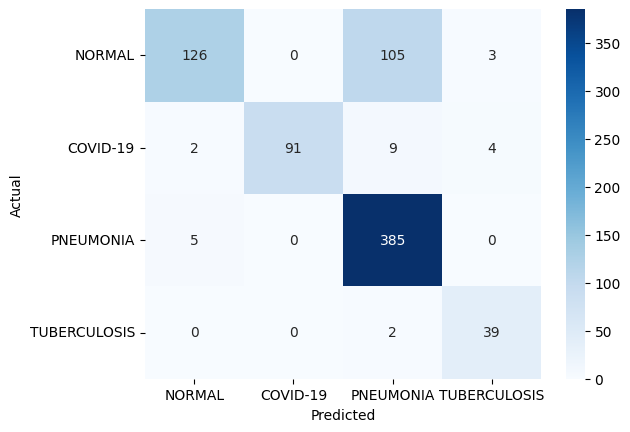

In [ ]:
# Result Processing for a better understanding of the results
categories = ['NORMAL', 'COVID-19', 'PNEUMONIA', 'TUBERCULOSIS']
new_category_order = [1, 0, 2, 3] # To put the categories in an order that makes sense
print(classification_report(all_labels, all_predictions, target_names = categories, labels = new_category_order)) # An evaluation report using the output and the labels from scikit

# A confusion Matrix Heatmap to organize the true vs. predicted classifications
cm = confusion_matrix(all_labels, all_predictions, labels = new_category_order)
seaborn.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = categories, yticklabels = categories) # annot = True adds actual numbers in each square

# Labeling Axes
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()